# **Herzlich Willkommen zum ersten Coding-Abschnitt der KI-Games!**

In dieser Vorlesung werden wir die Grundlagen von Bildverarbeitung lernen. Zunächst geht es darum, ein grundlegendes Verständnis dafür zu entwickeln:

Was ist ein digitales Bild und wie kann ein Computer es „sehen“?

Wie können medizinische Daten (z. B. Bilder oder klinische Werte) in Zahlen umgewandelt werden?

Wie kann man mit einfachen Methoden erste Zusammenhänge in Daten erkennen?

# Was sind Pakete in Python?

In Python arbeitet man in der Regel mit sogenannten Paketen (engl. libraries). Ein Paket ist eine Sammlung von vorgefertigten Funktionen, die bestimmte Aufgaben übernehmen.

Ohne Pakete müsste man viele grundlegende Dinge selbst programmieren, zum Beispiel:
- Bilder laden und anzeigen
- mathematische Berechnungen durchführen
- Machine-Learning-Modelle erstellen

Pakete ermöglichen es daher, sich auf das Verständnis der Methoden zu konzentrieren, statt auf deren technische Umsetzung.

In diesem Kurs verwenden wir unter anderem folgende Pakete:

- numpy: arbeitet mit Zahlen und Matrizen (Grundlage für Bilddaten)
- matplotlib: dient zur Darstellung von Bildern und Diagrammen
- PIL (Pillow): wird zum Laden und Verarbeiten von Bildern genutzt
- requests: ermöglicht das Laden von Daten aus dem Internet

Wenn wir ein Paket importieren, zum Beispiel:

import numpy as np

bedeutet das, dass wir das Paket numpy laden und ihm den kurzen Namen "np" geben, um es im weiteren Code einfacher verwenden zu können.

Wichtig ist: Python selbst bietet nur grundlegende Funktionen. Erst durch Pakete wird es zu einem leistungsfähigen Werkzeug für Datenanalyse und Machine Learning.

In [1]:
# ================================
# Setup
# ================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

Wir haben die notwendigen Pakete nun installiert und können nun das erste Fundusbild herunterladen.

Dafür nehmen wir ein Bild aus dem Datensatz der KI-Games, die ersten drei Zeilen laden das Fundusbild aus dem Datensatz herunter und weisen es der Variable img zu.

Anschließend wird das Bild dargestellt. Experimentiere mit den verschiedenen Parametern herum.
1.   Wie ändert man den Titel des Bildes?
2.   Was passiert, wenn man die Bildachsen aktiviert? Wofür stehen die Koordinaten?





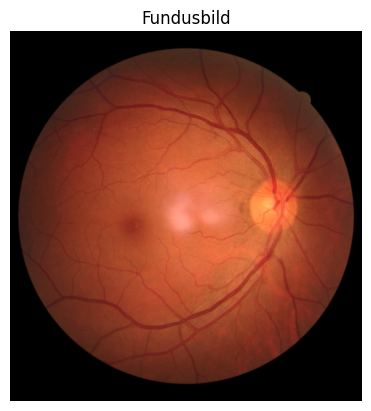

In [2]:
# Fundusbild laden

url = "https://raw.githubusercontent.com/MertenDMallwitz/KI-Games-Material/main/Diabetes%20Bilder/100_r2.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))
img_pil = img
img = np.array(img)

# Bild wird dargestellt
plt.imshow(img) #Lädt das Bild in die Grafik herein
plt.title("Fundusbild") #Bestimmt den Titel der Grafik
plt.axis("off") #Deaktiviert die Achsenbeschriftung der Grafik
plt.show() #Stellt die Grafik dar.

##Gruppendiskussion: Bildqualität

Diskussionsfragen:
- Was fällt Ihnen zwischen Makula und Sehnerv auf?
- Welche Probleme können dadurch entstehen?
- Wie könnte sich dies auf die Diagnose auswirken?
- Welche Lösungen wären denkbar (technisch oder organisatorisch)?

---


Nun wird das Bild ohne Farben in einem Grauton dargestellt. Die Werte des Grautons ergeben sich aus dem Durchschnittswert der Rot-, Grün- und Blauwerte jedes einzelnen Pixels. Solche "Transformationen" von rohen Bildern sind für die spätere Anwendung in Algorithmen von essentieller Bedeutung.

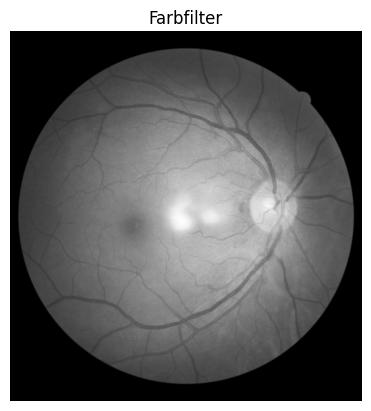

Shape: (1824, 1736, 3)
Dtype: uint8


In [3]:
gray = np.mean(img, axis=2)
plt.imshow(gray, cmap='gray')
plt.title("Farbfilter")
plt.axis("off")
plt.show()
print("Shape:", img.shape)
print("Dtype:", img.dtype)

#**Teil 2: Bilder als Zahlen**

Ein zentrales Konzept für das gesamte Machine Learning ist: Ein Computer verarbeitet keine Bilder im menschlichen Sinn, sondern ausschließlich Zahlen.

Wenn wir ein Bild in Python laden und mit NumPy umwandeln, passiert genau das:
Das Bild wird dabei in eine sogenannte mehrdimensionale Matrix (Array) umgewandelt.

---
## 1. Aufbau eines Bildes

Die Ausgabe von:

`print(img_array.shape)`

zeigt typischerweise drei Werte, zum Beispiel:

*   (512, 512, 3)

Diese bedeuten:

*   512: Höhe des Bildes (Anzahl der Pixel in vertikaler Richtung)
*   512: Breite des Bildes (Anzahl der Pixel in horizontaler Richtung)
*   3: Anzahl der Farbkanäle (Rot, Grün, Blau)

---

## 2. Was ist ein Pixel?

Ein Pixel ist der kleinste Bildpunkt. In einem Farbbild besteht jeder Pixel aus drei Zahlen:

1. Intensität von Rot

2. Intensität von Grün

3. Intensität von Blau

Jede dieser Zahlen liegt typischerweise zwischen 0 und 255:

*   0 = keine Intensität (schwarz)

* 255 = maximale Intensität



Gesamtzahl der Pixel

Die Gesamtanzahl der Pixel ergibt sich aus:

Höhe × Breite

Bei einem Bild der Größe (512, 512, 3) sind das:

512 × 512 = 262144 Pixel

Jeder dieser Pixel enthält drei Zahlen.

---

## 3. Warum ist das wichtig für Machine Learning?

Für ein Machine-Learning-Modell ist ein Bild nichts anderes als eine große Sammlung von Zahlen. Das bedeutet Modell erkennen lediglich Muster in Zahlenwerten, die als „Gefäße“ oder „Blutungen“ interpretiert werden.
Das Ziel von Machine Learning ist es, Zusammenhänge zwischen diesen Zahlen zu lernen, zum Beispiel: Alle Bildverarbeitungsschritte (z. B. Graustufen, Normalisierung, Skalierung) verändern nicht das „Bild“ im menschlichen Sinn, sondern die zugrunde liegenden Zahlen.

Diese numerische Darstellung ist die Grundlage für alle weiteren Schritte.

---

## 4. Aufgaben zu Teil 2:

## Aufgabe 1: Bilddimensionen verstehen
Geben Sie die einzelnen Dimensionen des Bildes getrennt aus.

Hinweis:
- Nutzen Sie `img_array.shape`

Frage:
- Wie viele Farbkanäle hat das Bild?

In [4]:
# ================================
# Aufgabe 1
# ================================
img_array = np.array(img)


## Aufgabe 2: Einzelnen Pixel untersuchen
Wählen Sie einen beliebigen Pixel aus (z. B. in der Mitte des Bildes) und geben Sie dessen Werte aus.

Hinweis:
- Zugriff über `img_array[x, y]`

Fragen:
- Welche drei Werte erhalten Sie?
- Was bedeuten diese Werte?

---


In [5]:
# ================================
# Aufgabe 2
# ================================

### Aufgabe 3: Eigenes Graustufenbild erstellen
Verändern Sie die Graustufenberechnung:

Statt Mittelwert:
- Verwenden Sie nur den roten Kanal

Hinweis:
```python
img_red = img_array[:, :, 0]

In [6]:
# ================================
# Aufgabe 3
# ================================

## Aufgabe 4: Gruppendiskussion klinische Aspekte

* Welche Regionen des Bildes sind besonders interessant?
* Was könnte ein sehr heller Pixel (nahe 255) im Fundusbild darstellen?
* Was könnte ein sehr dunkler Pixel (nahe 0) bedeuten?
* Welche klinischen Informationen gehen verloren, wenn ein Bild in Graustufen umgewandelt wird?
* Könnte dies die Erkennung bestimmter Pathologien (z. B. Blutungen, Exsudate) beeinflussen?
* Welche Vorteile hat die Umwandelung in Graustufen?

---
## Aufgabe 5: Histogramm interpretieren

Beschreiben Sie das Histogramm der Pixelintensitäten.

Fragen:

1. Gibt es eher dunkle oder helle Pixel?

2. Was könnte das über das Bild aussagen (z. B. Beleuchtung, Kontrast, Ausschnitt)?

3. Verändern Sie die Anzahl der Bins (z. B. 20, 100) und beobachten Sie den Unterschied
4. Setzen Sie den unteren Threshold größer als 1 mit folgendem Stück Code `gray_flattened = gray_flattened[gray_flattened>1]`
5. Wie verändert das das Histogramm? Können dadurch neue Aussagen über das Bild gewonnen werden.
6. Welche anderen Arten von Diagrammen kennen Sie? Welche wären für die Darstellung besonders geeignet? Schauen Sie sich Beispiel unter folgendem Link (https://matplotlib.org/stable/gallery/index.html) an und schauen Sie ob eines dieser Diagramme geeignet wäre.

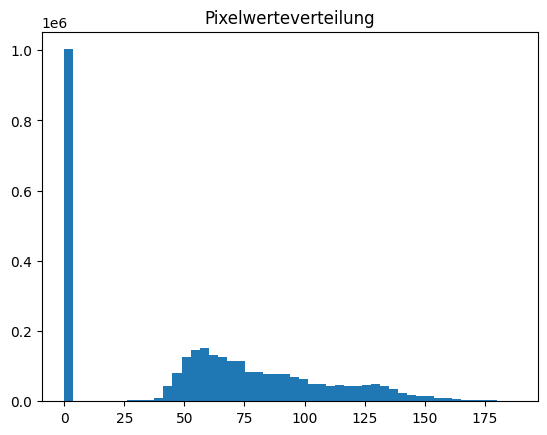

In [7]:
# ================================
# Pixelintensitätshistogramm
# ================================
gray = np.mean(img_array, axis=2) # Setup bitte nicht verändern
gray_flattened= gray.flatten() # Setup bitte nicht verändern


# Der folgende Abschnitt plottet das Histogram
plt.hist(gray_flattened, bins=50)
plt.title("Pixelwerteverteilung")
plt.show()



# **Teil 3: Bildtransformationen für Machine Learning**

Bevor medizinische Bilder in ein ML-Modell eingegeben werden, werden sie oft **vorverarbeitet**.  
Das nennt man **Preprocessing**.

Warum ist das wichtig?

- Bilder können unterschiedliche Größen haben
- Helligkeit und Kontrast können variieren
- Bilder können leicht gedreht oder gespiegelt sein
- Manche Bilder enthalten störendes Rauschen

Durch Bildtransformationen können wir Daten **vereinheitlichen**, **robuster machen** und manchmal auch die **Generalisierung** eines Modells verbessern.

In diesem Abschnitt schauen wir uns einige wichtige grundlegende Transformationen an:

1. **Resize** – Bild auf eine einheitliche Größe bringen  
2. **Crop** – wichtigen Bildausschnitt auswählen  
3. **Rotation und Spiegelung** – Lageveränderungen simulieren  
4. **Helligkeit / Kontrast** – Aufnahmeunterschiede ausgleichen  
5. **Normalisierung** – Pixelwerte für ML vorbereiten  

>Wichtig:  
Nicht jede Transformation ist in der Medizin automatisch sinnvoll.  
Bei klinischen Bilddaten muss man immer prüfen, ob diagnostisch relevante Informationen verändert oder verfälscht werden.
---
### Hinweis zur Datenstruktur

Das Bild liegt als NumPy-Array vor:

- Shape: (Höhe, Breite, Kanäle)
- Datentyp: uint8 (Werte 0–255)

Viele Bildoperationen nutzen:
- NumPy → für direkte Pixelmanipulation
- PIL → für komfortable Transformationen (Resize, Rotation, etc.)

Wir wechseln daher bewusst zwischen beiden Darstellungen.

## Aufgabe 6: Resize – Bilder auf gleiche Größe bringen

Viele ML-Modelle erwarten, dass alle Bilder dieselbe Größe haben.  
Deshalb werden Bilder oft vor dem Training skaliert.

### 1. Coden
Verkleinern Sie das Bild auf eine feste Größe, z. B. **30 x 30 Pixel**, und stellen Sie Original und Resize-Version nebeneinander dar. Dafür müssen Sie lediglich die Werte in u.g. Code ändern.

### 2. Einordnen:
1. Warum ist eine einheitliche Bildgröße für ML hilfreich?
2. Welche diagnostischen Informationen könnten durch Verkleinerung verloren gehen?
3. Wann wäre Resize bei Fundusbildern unproblematisch?

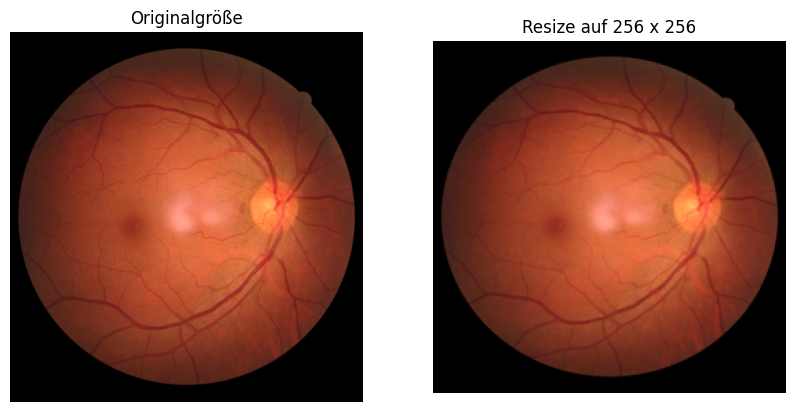

Originalgröße: (1736, 1824)
Neue Größe: (256, 256)


In [8]:
# ================================
# Aufgabe 6: Resize
# ================================
img_resized = img_pil.resize((256, 256))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Originalgröße")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_resized)
plt.title("Resize auf 256 x 256")
plt.axis("off")

plt.show()

print("Originalgröße:", img_pil.size)
print("Neue Größe:", img_resized.size)

## Aufgabe 7: Crop – relevanten Bildausschnitt auswählen

Beim **Cropping** wird nur ein Teil des Bildes verwendet.  
Das kann sinnvoll sein, wenn Randbereiche wenig Information enthalten oder störend sind.

### 1. Coden
Experimentieren Sie mit verschiedenen Größen des Crops, indem Sie die Variable `crop_scale` verändert!

Fragen:
- Was bleibt sichtbar?
- Was geht verloren?
- Wie können Sie das Bild anders zentrieren?

### 2. Einordnen
- Wann könnte Cropping sinnvoll sein?
- Was passiert, wenn wichtige pathologische Befunde am Rand liegen?

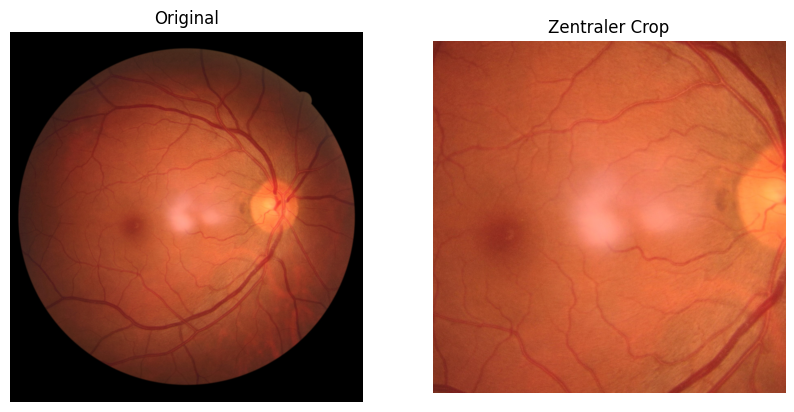

Original-Shape: (1824, 1736, 3)
Crop-Shape: (868, 868, 3)


In [9]:
# ================================
# Aufgabe 7: Crop
# ================================
h, w, _ = img.shape

crop_scale=2

crop_size = min(h, w) // crop_scale

start_y = h // crop_scale - crop_size // crop_scale
start_x = w // crop_scale - crop_size // crop_scale

img_cropped = img[start_y:start_y+crop_size, start_x:start_x+crop_size]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_cropped)
plt.title("Zentraler Crop")
plt.axis("off")

plt.show()

print("Original-Shape:", img.shape)
print("Crop-Shape:", img_cropped.shape)

## Aufgabe 8: Rotation und Spiegelung

ML-Modelle sollen oft robust gegenüber kleinen Lageveränderungen sein.  
Dafür werden Bilder manchmal rotiert oder gespiegelt.

### 1. Coden
Erstellen Sie:
- eine um 90° rotierte Version
- eine horizontal gespiegelte Version

indem Sie bei `img_90Gradrotiert` und `img_horizontalgespiegelt` die Rotation ändern.



### 2. Einordnen
- Welche Rotation könnten für Fundusbilder sinnvoll sein? Wirkt das Bild noch anatomisch plausibel?
- Wann könnte Spiegelung problematisch sein?
- Könnte links/rechts oder oben/unten klinisch relevant sein?
- Gibt es andere Funktionen als `.rotate()` um das Bild zu spiegeln?

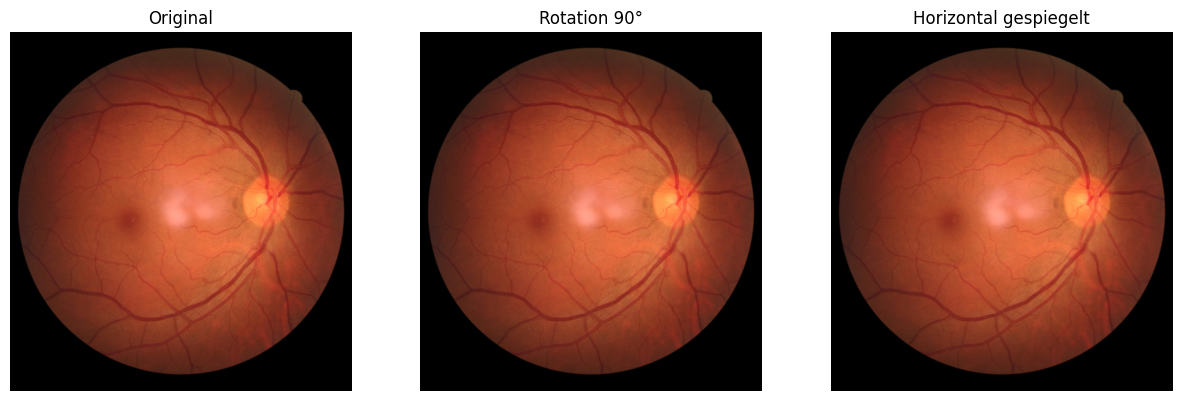

In [10]:
# ================================
# Aufgabe 8: Rotation und Spiegelung
# ================================
img_90Gradrotiert = img_pil.rotate(0)
img_horizontalgespiegelt = img_pil.rotate(0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_90Gradrotiert)
plt.title("Rotation 90°")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_horizontalgespiegelt)
plt.title("Horizontal gespiegelt")
plt.axis("off")

plt.show()

## Aufgabe 9: Normalisierung – Vorbereitung für ML

Viele ML-Modelle arbeiten besser, wenn Pixelwerte in einem einheitlichen Bereich liegen, z. B. zwischen **0 und 1** statt zwischen **0 und 255**.

Das nennt man **Normalisierung**.

### 1. Coden
Wandeln Sie das Bild in ein NumPy-Array um und normalisieren Sie die Pixelwerte. Dazu müssen Sie:
1. Den Variablentyp von img von uint8 zu float32 ändern.
2. Diese veränderte Variable durch 255.0 teilen

 > Recherchieren Sie dazu im Internet zu brauchbaren, vordefinierten Funktionen!

Vorher:
Min: 0 Max: 255 Dtype: uint8

Nachher:
Min: 0.0 Max: 1.0 Dtype: float32


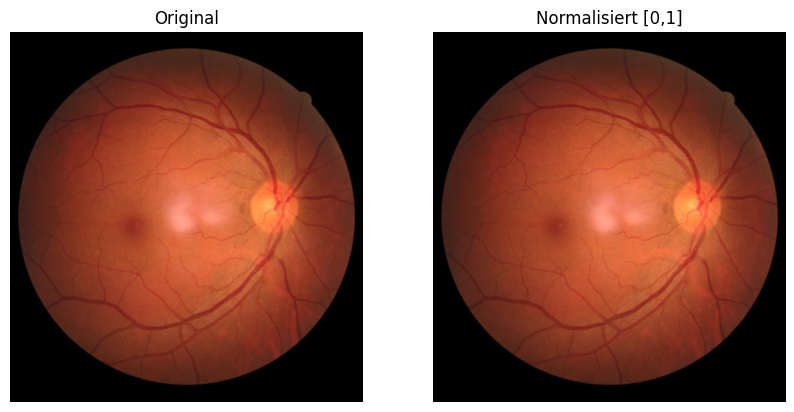

In [11]:
# ================================
# Aufgabe 10: Normalisierung
# ================================
img_float =  # Hier Funktion Einsetzen, die aus img img_float mit floatwerten macht
img_norm = # Hier die neue Variable img_float durch 255 teilen!

print("Vorher:")
print("Min:", img.min(), "Max:", img.max(), "Dtype:", img.dtype)

print("\nNachher:")
print("Min:", img_norm.min(), "Max:", img_norm.max(), "Dtype:", img_norm.dtype)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_array)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_norm)
plt.title("Normalisiert [0,1]")
plt.axis("off")

plt.show()

## Abschluss: Welche Transformationen sind sinnvoll?

Nicht jede technisch mögliche Bildtransformation ist auch klinisch sinnvoll.

### Diskussionsfragen
- Welche Transformationen würden Sie für Fundusbilder erlauben?
- Welche Transformationen würden Sie nur vorsichtig einsetzen?
- Welche Transformationen könnten wichtige pathologische Informationen verfälschen?
- Warum ist es in der medizinischen KI besonders wichtig, Preprocessing kritisch zu prüfen?
